# S2.2 高性能路径：XGBoost 训练与贡献度分析

## 步骤一：导入所需库

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing (sklearn) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # 用于处理可能的缺失值

# --- Model (XGBoost) ---
import xgboost as xgb
from sklearn.metrics import classification_report

# --- Settings ---
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

## 步骤 2：定义常量和路径

In [8]:
# --- 路径定义 ---
RAW_DATA_FILE = os.path.join('..', 'data', 'raw', 'california_raw_data.csv')
NLP_FEATURE_FILE = os.path.join('..', 'data', 'processed', 'california_nlp_features.pkl')
COLUMNS_CONFIG_FILE = os.path.join('..', 'config', 'columns_to_keep.txt')
OUTPUT_DIR = os.path.join('..', 'data', 'processed')
CONTRIBUTION_FILE = os.path.join(OUTPUT_DIR, 'california_high_contribution_features2.csv')
MODEL_FILE = os.path.join('..', 'models', 'california_xgboost_model.pkl')

# --- 关键假设 ---
# 1. 我们要预测的目标列名
TARGET_COLUMN = 'accidenttype' 

# 2. 我们在 S2.2 中已用 LLM 编码过的叙述列名
#    (必须从 X_baseline 中移除它)
NARRATIVE_COLUMN = 'narrative' 

print(f"原始数据: {RAW_DATA_FILE}")
print(f"NLP特征: {NLP_FEATURE_FILE}")
print(f"特征配置文件: {COLUMNS_CONFIG_FILE}")
print(f"目标列 (假设): {TARGET_COLUMN}")

原始数据: ..\data\raw\california_raw_data.csv
NLP特征: ..\data\processed\california_nlp_features.pkl
特征配置文件: ..\config\columns_to_keep.txt
目标列 (假设): accidenttype


## 步骤 3：加载所有数据源

In [3]:
# 1. 加载原始数据
try:
    df_raw = pd.read_csv(RAW_DATA_FILE, low_memory=False)
    print(f"原始数据加载成功。形状: {df_raw.shape}")
except FileNotFoundError:
    print(f"错误: 未找到 {RAW_DATA_FILE}。请先运行 01_data_acquisition.ipynb。")
    # 在脚本中，这里应该 raise an error

# 2. 加载 NLP 特征
try:
    with open(NLP_FEATURE_FILE, 'rb') as f:
        X_nlp = pickle.load(f)
    print(f"NLP 特征加载成功。形状: {X_nlp.shape}")
except FileNotFoundError:
    print(f"错误: 未找到 {NLP_FEATURE_FILE}。请先运行 02_llm_feature_engineering.ipynb。")

# 3. 加载 72 个风险条件列名
try:
    with open(COLUMNS_CONFIG_FILE, 'r') as f:
        COLUMNS_TO_KEEP = [line.strip() for line in f if line.strip()]
    print(f"成功加载 {len(COLUMNS_TO_KEEP)} 个风险条件列名。")
except FileNotFoundError:
    print(f"错误: 未找到 {COLUMNS_CONFIG_FILE}。")

原始数据加载成功。形状: (11383, 161)
NLP 特征加载成功。形状: (11383, 768)
成功加载 49 个风险条件列名。


## 步骤 4：准备标签 (y) 和数据对齐

In [4]:
# --- 1. 准备 y (目标标签) ---
if TARGET_COLUMN in df_raw.columns:
    y = df_raw[TARGET_COLUMN] # 提取出事故类型这一列存入y变量
    
    # --- 2. 处理 y 中的缺失值 (关键步骤) ---
    print(f"处理 y ({TARGET_COLUMN}) 之前的行数: {len(y)}")
    y = y.dropna()
    print(f"处理 y 缺失值之后的行数: {len(y)}")
    
    # --- 3. 标签编码，把文本标签转化成数字 ---
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # 保存标签的含义
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n标签 (y) 编码映射: {label_mapping}")
    
    # --- 4. 数据对齐 ---
    # 删除刚刚事故类型缺失对应的整行
    # 筛选 df_raw 以匹配 y
    df_aligned = df_raw.loc[y.index]
    
    # 将 X_nlp (Numpy 数组) 转换为带索引的 DataFrame，以便对齐
    try:
        X_nlp_df = pd.DataFrame(X_nlp, index=df_raw.index)
        X_nlp_aligned = X_nlp_df.loc[y.index]
        print(f"\n数据对齐完成。")
        print(f"y 形状: {y_encoded.shape}")
        print(f"df_aligned (用于 X_baseline) 形状: {df_aligned.shape}")
        print(f"X_nlp_aligned (NLP 特征) 形状: {X_nlp_aligned.shape}")
    except ValueError:
        print(f"错误: X_nlp (形状 {X_nlp.shape}) 与 df_raw (形状 {df_raw.shape}) 的行数不匹配。")
        print("请（approaching）确保 02_llm_feature_engineering.ipynb 是基于 01_data_acquisition.ipynb 的完整数据运行的。")

else:
    print(f"错误: 目标列 '{TARGET_COLUMN}' 不在 {RAW_DATA_FILE} 中。请在“步骤1”中更正。")

处理 y (accidenttype) 之前的行数: 11383
处理 y 缺失值之后的行数: 11383

标签 (y) 编码映射: {'Broken train collision': np.int64(0), 'Derailment': np.int64(1), 'Explosion-detonation': np.int64(2), 'Fire/violent rupture': np.int64(3), 'Head on collision': np.int64(4), 'Hwy-rail crossing': np.int64(5), 'Obstruction': np.int64(6), 'Other (describe in narrative)': np.int64(7), 'Other impacts': np.int64(8), 'Raking collision': np.int64(9), 'Rear end collision': np.int64(10), 'Side collision': np.int64(11)}

数据对齐完成。
y 形状: (11383,)
df_aligned (用于 X_baseline) 形状: (11383, 161)
X_nlp_aligned (NLP 特征) 形状: (11383, 768)


处理基数爆炸

## 步骤 5：创建基线特征 (X_baseline)

In [5]:
# 1. 筛选出 72 列，并移除 Narrative 列
baseline_cols = [col for col in COLUMNS_TO_KEEP if col in df_aligned.columns]
if NARRATIVE_COLUMN in baseline_cols:
    baseline_cols.remove(NARRATIVE_COLUMN)
    print(f"已从基线特征中移除 '{NARRATIVE_COLUMN}'。")

df_baseline = df_aligned[baseline_cols]

# 2. 自动检测数值列和类别列
# (这是一个健壮的启发式方法)
numeric_cols = df_baseline.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_baseline.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"发现 {len(numeric_cols)} 个数值特征。")
print(f"发现 {len(categorical_cols)} 个类别特征。")

# 【新增】移除高基数列
# 我们移除所有唯一值 > 150 的列 (188 和 186 也包含在内)
HIGH_CARDINALITY_COLS_TO_REMOVE = [
    'date', 
    'milepost',
    'trainnumber', 
    'location', 
    'station',
    'maintenancerailroadcode',
    'subdivision',
    'time',
    'trackdensity',
    'trackname'
]

# 从数值和类别列表中“清洗”掉这些列
# (使用 .copy() 来安全地修改列表)
numeric_cols_clean = numeric_cols.copy()
for col in HIGH_CARDINALITY_COLS_TO_REMOVE:
    if col in numeric_cols_clean:
        numeric_cols_clean.remove(col)

categorical_cols_clean = categorical_cols.copy()
for col in HIGH_CARDINALITY_COLS_TO_REMOVE:
    if col in categorical_cols_clean:
        categorical_cols_clean.remove(col)

print(f"\n移除高基数列后：剩 {len(numeric_cols_clean)} 个数值特征。")
print(f"移除高基数列后：剩 {len(categorical_cols_clean)} 个类别特征。")
# --- 新增步骤结束 ---

# --- (!!! 在这里插入新的诊断代码 !!!) ---
print("\n--- 检查 *剩余* (approaching) 类别列的基数 ---")
if len(categorical_cols_clean) > 0:
    remaining_unique_counts = df_baseline[categorical_cols_clean].nunique().sort_values(ascending=False)
    # 我们打印 *所有* (approaching) 剩余的，而不只是 Top 10，看看问题出在哪
    print(remaining_unique_counts) 
else:
    print("所有（approaching）类别列都已被移除。")

# 3. 创建预处理 Pipeline
# (我们使用 SimpleImputer 来处理数据中可能（approaching）残余的 NaN)

# 为数值特征：填充中位数，然后缩放
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# 为类别特征：填充最常见值，然后独热编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    # sparse_output=False 使其返回密集矩阵，便于后续合并
])

# 4. 使用 ColumnTransformer 组合 Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols_clean),
        ('cat', categorical_transformer, categorical_cols_clean)
    ],
    remainder='drop' # 保留我们可能（approaching）遗漏的任何列
)

# 5. 拟合和转换 X_baseline
print("正在处理 X_baseline...")
X_baseline = preprocessor.fit_transform(df_baseline)

# 6. 获取可解释的特征名称 (!! 关键 !!)
baseline_feature_names = preprocessor.get_feature_names_out()

print(f"X_baseline 创建成功。")
print(f"X_baseline 形状: {X_baseline.shape}")
print(f"前5个可解释特征名: {baseline_feature_names[:5]}")

已从基线特征中移除 'narrative'。
发现 27 个数值特征。
发现 21 个类别特征。

移除高基数列后：剩 27 个数值特征。
移除高基数列后：剩 19 个类别特征。

--- 检查 *剩余* (approaching) 类别列的基数 ---
equipmenttype              14
adjunctname1               14
class                      11
adjunctname2               11
jointtrackclass            10
trackclass                  9
weathercondition            6
adjunctname3                6
methodofoperation           5
tracktype                   4
visibility                  4
jointtracktype              4
remotecontrollocomotive     4
traindirection              4
equipmentattended           2
recordedestimatedspeed      2
signalization               2
firstcarloaded              2
passengerstransported       2
dtype: int64
正在处理 X_baseline...
X_baseline 创建成功。
X_baseline 形状: (11383, 143)
前5个可解释特征名: ['num__accidentmonth' 'num__hazmatcars' 'num__temperature'
 'num__trainspeed' 'num__maximumspeed']


## 步骤 6：创建混合特征 (X_combined)

In [6]:
# 将 X_nlp_aligned (Pandas) 转换为 Numpy 数组
X_nlp_array = X_nlp_aligned.values

print(f"X_baseline 形状: {X_baseline.shape}")
print(f"X_nlp_array 形状: {X_nlp_array.shape}")

# 水平（approaching）拼接 (axis=1)
X_combined = np.concatenate([X_baseline, X_nlp_array], axis=1)

print(f"X_combined (混合特征) 创建成功。最终形状: {X_combined.shape}")

X_baseline 形状: (11383, 143)
X_nlp_array 形状: (11383, 768)
X_combined (混合特征) 创建成功。最终形状: (11383, 911)


## 步骤 7：训练 S2.2 XGBoost 模型

In [10]:
# 1. 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print(f"训练集 X: {X_train.shape}, y: {y_train.shape}")
print(f"测试集 X: {X_test.shape}, y: {y_test.shape}")

# 2. 初始化 XGBoost 分类器
# (我们使用 GPU 'device=cuda' 来加速训练)
model = xgb.XGBClassifier(
    n_estimators=200,          # 树的数量
    learning_rate=0.1,         # 学习率
    max_depth=6,               # 树的最大深度
    device='cuda',             # (!! 关键 !!) 使用 GPU
    eval_metric='mlogloss',    # 多分类对数损失
    objective='multi:softmax', # 多分类目标
    num_class=len(label_mapping), # 告知模型有多少个类别
    random_state=42
)

# 3. 训练模型
print("\n正在训练 XGBoost 模型 (使用 GPU)...")
model.fit(X_train, y_train)
print("模型训练完毕。")

# 4. 评估模型性能
print("\n--- 模型性能评估 (在测试集上) ---")
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_mapping.keys(), zero_division=0)
print(report)

# 5. (可选) 保存模型
os.makedirs(os.path.dirname(MODEL_FILE), exist_ok=True)
with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model, f)
print(f"\n模型已保存到: {MODEL_FILE}")

训练集 X: (8537, 911), y: (8537,)
测试集 X: (2846, 911), y: (2846,)

正在训练 XGBoost 模型 (使用 GPU)...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:02:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:02:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


模型训练完毕。

--- 模型性能评估 (在测试集上) ---
                               precision    recall  f1-score   support

       Broken train collision       0.00      0.00      0.00        10
                   Derailment       0.77      0.97      0.86      1684
         Explosion-detonation       0.00      0.00      0.00         3
         Fire/violent rupture       1.00      0.29      0.45        41
            Head on collision       1.00      0.20      0.33        40
            Hwy-rail crossing       0.72      0.83      0.77       289
                  Obstruction       0.58      0.15      0.23       102
Other (describe in narrative)       1.00      0.05      0.10        40
                Other impacts       0.82      0.35      0.49       263
             Raking collision       0.57      0.09      0.15        46
           Rear end collision       0.93      0.23      0.37        60
               Side collision       0.69      0.57      0.62       268

                     accuracy              

## 步骤 8：S2.2 目标：提取“高贡献特征”

In [11]:
# 1. 获取所有特征的重要性
all_importances = model.feature_importances_

# 2. 创建所有特征的名称列表
# (我们已经有了 'baseline_feature_names')
nlp_feature_names = [f'nlp_feat_{i}' for i in range(X_nlp_array.shape[1])]
all_feature_names = np.concatenate([baseline_feature_names, nlp_feature_names])

# 3. 创建一个 Series (便于筛选)
feat_imp_series = pd.Series(all_importances, index=all_feature_names)

# 4. (!! 核心步骤 !!) 只筛选出基线特征的重要性
baseline_importances = feat_imp_series.loc[baseline_feature_names]

# 5. 排序并获取 S2.3 所需的“高贡献特征”
high_contribution_features = baseline_importances.sort_values(ascending=False)

print(f"--- S2.2 最终结果：高贡献风险条件 (Top 30) ---")
print(high_contribution_features.head(30))

# 6. 保存这些特征以用于 S2.3
os.makedirs(OUTPUT_DIR, exist_ok=True)
high_contribution_features.to_csv(CONTRIBUTION_FILE, header=['importance_score'])
print(f"\n高贡献特征已保存到: {CONTRIBUTION_FILE}")

--- S2.2 最终结果：高贡献风险条件 (Top 30) ---
cat__equipmentattended_No                       0.027972
cat__tracktype_Yard                             0.019910
num__maximumspeed                               0.012899
num__firstcarposition                           0.011154
cat__tracktype_Main                             0.008434
cat__class_1L                                   0.008404
cat__jointtracktype_Main                        0.007409
cat__equipmenttype_Freight Train                0.007064
cat__methodofoperation_Other Than Main Track    0.006869
cat__class_CL                                   0.005519
cat__equipmenttype_Spec. MoW Equip.             0.005252
cat__jointtrackclass_6                          0.004879
num__loadedpassengercars                        0.004724
cat__equipmenttype_Maint./inspect Car           0.004348
cat__trackclass_1                               0.004178
num__trainspeed                                 0.003619
cat__tracktype_Siding                           0.003

## 步骤 8.1: 模型参数敏感性验证

In [12]:
# --- 新增步骤：S2.2 模型敏感性验证 ---
# 目的：验证特征重要性排序是否稳定，不受随机种子或超参数微调的剧烈影响

from scipy.stats import spearmanr
import xgboost as xgb # 确保引用

def run_sensitivity_test(X, y, feature_names):
    print("\n========== 开始 XGBoost 参数敏感性分析 ==========")
    
    # 1. 定义几组对比实验配置
    configs = {
        'Baseline': { # 当前基准 (参考你步骤7的参数)
            'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 42
        },
        'Seed_Change': { # 测试随机性：只改随机种子
            'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 999
        },
        'Shallow_Tree': { # 测试欠拟合：浅树
            'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200, 'random_state': 42
        },
        'Deep_Tree': { # 测试过拟合：深树+低学习率
            'max_depth': 10, 'learning_rate': 0.05, 'n_estimators': 300, 'random_state': 42
        }
    }
    
    results = {}
    
    # 2. 循环训练并提取特征重要性
    for name, params in configs.items():
        print(f"正在测试配置: [{name}] ...")
        
        # 初始化并训练
        clf = xgb.XGBClassifier(
            objective='multi:softmax',
            num_class=len(set(y)),
            device='cuda', # 如果显存不够，可改为 'cpu'
            tree_method='hist', # 加速训练
            **params
        )
        clf.fit(X, y)
        
        # 记录该配置下的特征重要性
        results[name] = pd.Series(clf.feature_importances_, index=feature_names)
        
    # 3. 计算一致性指标
    base_imp = results['Baseline']
    print("\n---------- 分析结果 (相对于 Baseline) ----------")
    print(f"{'Config Name':<15} | {'Spearman Corr':<15} | {'Top 20 Overlap':<15}")
    print("-" * 55)
    
    for name, imp in results.items():
        if name == 'Baseline': continue
        
        # 指标1：整体排名的相关性 (Spearman)
        # 越接近 1.0，说明整体排序逻辑越一致
        corr, _ = spearmanr(base_imp, imp)
        
        # 指标2：前20个关键特征的重合率 (Overlap)
        # 越接近 100%，说明核心致因越稳定
        top20_base = set(base_imp.nlargest(20).index)
        top20_curr = set(imp.nlargest(20).index)
        overlap = len(top20_base.intersection(top20_curr)) / 20.0
        
        print(f"{name:<15} | {corr:.4f}          | {overlap:.1%}")
        
    print("===================================================")
    print("【解读提示】")
    print("1. Spearman Corr > 0.9: 说明特征重要性的整体排序非常稳定。")
    print("2. Top 20 Overlap > 80%: 说明核心风险特征（如Top 20）是'铁打的'，不是偶然得出的。")

# --- 执行验证 ---
# 注意：这里使用步骤 7 中生成的 X_train, y_train 和 步骤 8 中生成的 all_feature_names
try:
    run_sensitivity_test(X_train, y_train, all_feature_names)
except NameError as e:
    print(f"错误：缺少必要变量。请确保先运行步骤 7 (获取 X_train) 和 步骤 8 (获取 all_feature_names)。\n{e}")


========== 开始 XGBoost 参数敏感性分析 ==========
正在测试配置: [Baseline] ...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:08:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:08:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


正在测试配置: [Seed_Change] ...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:11:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:11:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


正在测试配置: [Shallow_Tree] ...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:12:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:12:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


正在测试配置: [Deep_Tree] ...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:13:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:13:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)



---------- 分析结果 (相对于 Baseline) ----------
Config Name     | Spearman Corr   | Top 20 Overlap 
-------------------------------------------------------
Seed_Change     | 1.0000          | 100.0%
Shallow_Tree    | 0.5647          | 65.0%
Deep_Tree       | 0.6863          | 80.0%
【解读提示】
1. Spearman Corr > 0.9: 说明特征重要性的整体排序非常稳定。
2. Top 20 Overlap > 80%: 说明核心风险特征（如Top 20）是'铁打的'，不是偶然得出的。


## 步骤 9：可视化结果

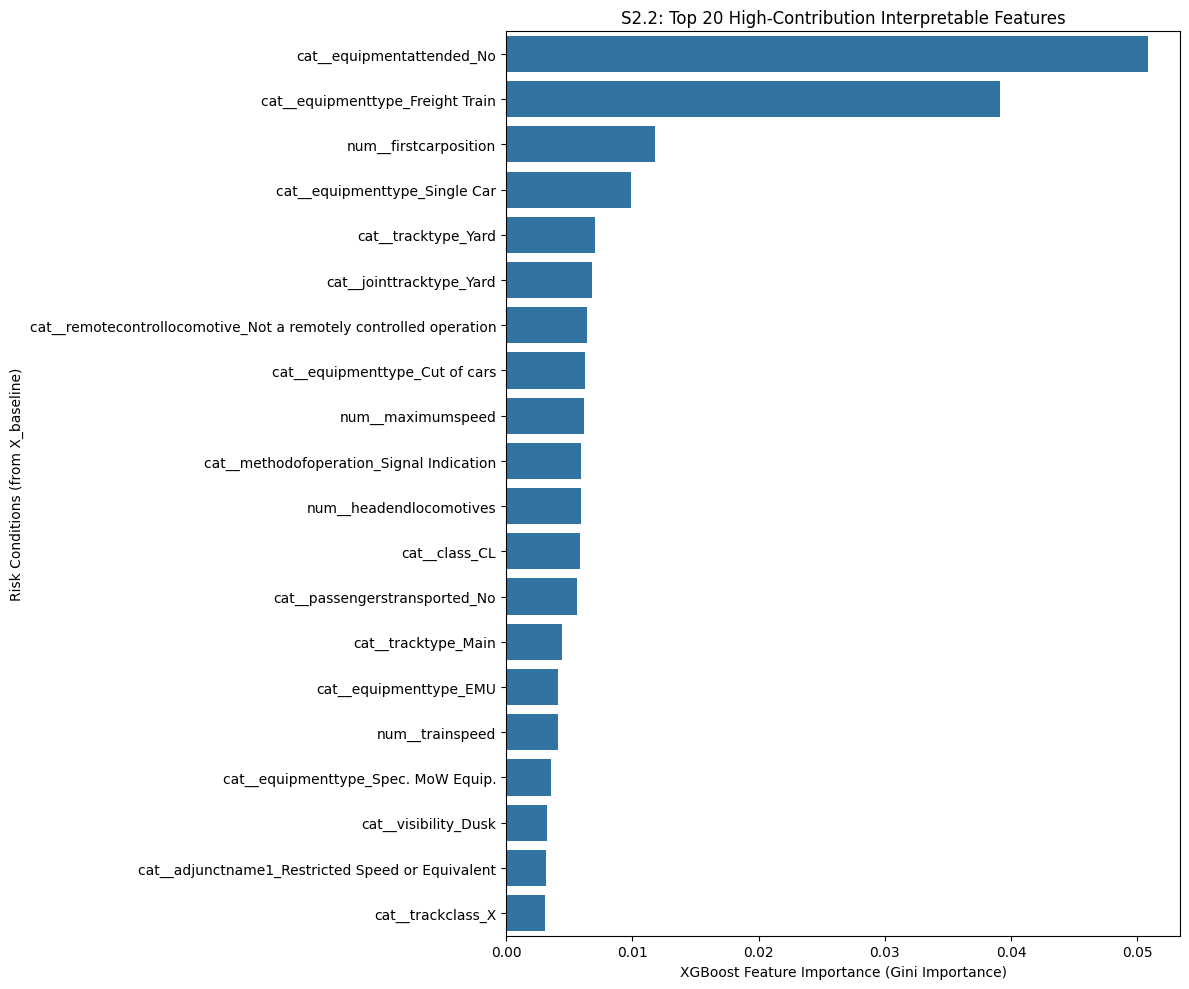

In [9]:
# 可视化 Top 20 的可解释特征
top_n = 20
plt.figure(figsize=(12, 10))
sns.barplot(
    x=high_contribution_features.head(top_n).values, 
    y=high_contribution_features.head(top_n).index
)
plt.title(f'S2.2: Top {top_n} High-Contribution Interpretable Features')
plt.xlabel('XGBoost Feature Importance (Gini Importance)')
plt.ylabel('Risk Conditions (from X_baseline)')
plt.tight_layout()
plt.show()